# COICOP — classifying short Hebrew item names with a multilingual encoder

This notebook adapts the [`text_classifier`](../../README.md) package to a very
different shape of problem from the [CLINC150 demo](../clinc150/): **short,
messy product names written in Hebrew**, classified into the international
[**COICOP 2018**](https://unstats.un.org/unsd/classifications/Econ) taxonomy of
household consumption (the codes national statistics offices use for CPI and
household-expenditure surveys).

Two things make this interesting:

1. **Cross-lingual.** The item names are Hebrew (`עוגיות סנדביץ`, `שמן שומשום`,
   `דלוורדה ניוקי`); the COICOP labels are English. A **multilingual** sentence
   encoder bridges the two in a shared embedding space.
2. **No labels yet.** We have the class *descriptions* and a list of *unlabeled*
   items. That rules out training the fusion model (which learns from labeled
   examples). So we run the package's encoder in **zero-shot retrieval** mode —
   the item ↔ class-description similarity signal, signal #1 of the five — and
   abstain with a confidence floor, the same human-in-the-loop story as CLINC150.

> **What changes once you have labels.** As soon as a few items per COICOP class
> are confirmed, the full `TrainingPipeline` (prototypes, kNN, BM25, XGBoost
> fusion, isotonic calibration, tuned abstention) applies unchanged — see the
> final section and the CLINC150 notebook. Zero-shot is the floor, not the ceiling.

## 1. Setup

Unlike the CLINC150 demo, this one is **not** offline: a real multilingual
bi-encoder is the whole point, so the notebook downloads one model (~1 GB the
first time, then cached) and needs `torch`.

```bash
pip install .                 # from the repo root (brings in sentence-transformers)
pip install pandas openpyxl matplotlib jupyter
```

In [1]:
import logging
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import text_classifier
from text_classifier.infrastructure.encoder import SentenceTransformerEncoder

logging.getLogger("text_classifier").setLevel(logging.WARNING)
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Hebrew prints right-to-left in most notebook frontends; nothing special needed.
print("text_classifier version:", text_classifier.__version__)
print("Python:", sys.version.split()[0])

text_classifier version: 0.1.0
Python: 3.11.15


In [2]:
def find_repo_root(start: Path | None = None) -> Path:
    # Walk upward until we find the package root, so the notebook runs from the
    # repo root or from this examples/ directory.
    here = (start or Path.cwd()).resolve()
    for candidate in (here, *here.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "text_classifier").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root from %s" % here)

REPO_ROOT = find_repo_root()
EXAMPLE_DIR = REPO_ROOT / "examples" / "coicop_hebrew"
BUILD = EXAMPLE_DIR / "build"          # downloaded workbook + classes.csv (git-ignored)

print("repository root :", REPO_ROOT)
print("example dir     :", EXAMPLE_DIR)
print("build dir       :", BUILD)

repository root : /home/user/Hybrid-retrieval-fusion-text-classifier
example dir     : /home/user/Hybrid-retrieval-fusion-text-classifier/examples/coicop_hebrew
build dir       : /home/user/Hybrid-retrieval-fusion-text-classifier/examples/coicop_hebrew/build


## 2. The COICOP class taxonomy

`prepare.py` downloads the UN Statistics Division's **COICOP 2018 hierarchies &
mappings** workbook once and turns one level of the hierarchy into the package's
`classes.csv` shape (`key,description`). COICOP nests four levels — division
(`01`), group (`01.1`), class (`01.1.1`), subclass (`01.1.1.1`). We emit the
**subclass** level, the granularity grocery products live at, and — because every
item here is food — keep **division 01** (food and non-alcoholic beverages).

Each `description` folds the official *title* together with the *intro* and
*includes* notes (e.g. "cornflakes, oatmeal, muesli, granola"). That concrete
product vocabulary is exactly what an item name echoes, so a richer description
is a stronger retrieval target — the first thing to tune for production.

In [3]:
cmd = [sys.executable, str(EXAMPLE_DIR / "prepare.py"),
       "--out", str(BUILD), "--level", "4", "--divisions", "01"]
print("$", " ".join(cmd), "\n")
result = subprocess.run(cmd, capture_output=True, text=True)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise SystemExit("prepare.py failed — see the error above.")

$ /usr/bin/python3 /home/user/Hybrid-retrieval-fusion-text-classifier/examples/coicop_hebrew/prepare.py --out /home/user/Hybrid-retrieval-fusion-text-classifier/examples/coicop_hebrew/build --level 4 --divisions 01 



wrote    69 rows -> /home/user/Hybrid-retrieval-fusion-text-classifier/examples/coicop_hebrew/build/classes.csv

69 COICOP level-4 classes (division(s) 01).
Next: open coicop_hebrew_classification.ipynb, or feed classes.csv to the library.



In [4]:
classes = pd.read_csv(BUILD / "classes.csv")
# The human-readable title is the part of the description before the first em dash.
classes["title"] = classes["description"].str.split(" — ").str[0]
print(f"{len(classes)} COICOP subclasses in division 01 (food & non-alcoholic beverages)\n")
display(classes[["key", "title"]].head(12))
print("\nExample of a full (rich) description used for retrieval:\n")
print(classes.loc[classes.key == "01.1.1.4", "description"].iloc[0])

69 COICOP subclasses in division 01 (food & non-alcoholic beverages)



,key,title
0,01.1.1.1,Cereals
1,01.1.1.2,Flour of cereals
2,01.1.1.3,Bread and bakery products
3,01.1.1.4,Breakfast cereals
4,01.1.1.5,"Macaroni, noodles, couscous and similar pasta ..."
5,01.1.1.9,Other milled cereal and grain products
6,01.1.2.1,Live land animals
7,01.1.2.2,"Meat, fresh, chilled or frozen"
8,01.1.2.3,"Meat, dried, salted, in brine or smoked"
9,01.1.2.4,"Offal, blood and other parts of slaughtered an..."



Example of a full (rich) description used for retrieval:

Breakfast cereals — Includes: cornflakes, oatmeal and oat flakes, muesli, granola and puffed cereals including puffed rice cakes breakfast cereals with nuts or dried fruit


## 3. The items to classify

`items.csv` has a single **`name`** column of short Hebrew product names — the
file shape you'd export from a catalog or receipt. These are *unlabeled*: our
job is to attach a COICOP code to each.

In [5]:
items = pd.read_csv(EXAMPLE_DIR / "items.csv")
names = items["name"].astype(str).tolist()
print(f"{len(names)} items to classify\n")
display(items)

15 items to classify



,name
0,עוגיות סנדביץ
1,וויט פיש
2,שמן שומשום
3,דייסת שיבולת שועל אגוזי לוז ומייפל 400גר
4,דייסת שיבולת שועל תפוחים וקינמון 400גר
5,דגני קורנפלקס בדבש 300גר
6,ג'לי בלי חמוץ 50גר
7,ג'לי בלי שיק פירות 50גר
8,ג'לי בלי שייק פירות 100גר
9,דרוסטה שוקולד לבן 100 גרם


## 4. A multilingual encoder (Hebrew + English)

The package's `SentenceTransformerEncoder` wraps any
[sentence-transformers](https://www.sbert.net) model and returns **L2-normalized**
embeddings (so a dot product is cosine similarity — a core invariant of the
package). We pick a model that is strong in **both Hebrew and English** so the
Hebrew item and the English class label land near each other:

| model | size | notes |
|---|---|---|
| `sentence-transformers/LaBSE` *(default here)* | ~1.8 GB | 109-language bitext model trained on translation pairs; the most robust **cross-lingual** matcher of the four for these Hebrew↔English items |
| `paraphrase-multilingual-mpnet-base-v2` | ~1.1 GB | 50+ languages; good and a bit lighter |
| `paraphrase-multilingual-MiniLM-L12-v2` | ~470 MB | faster/smaller, a touch weaker |
| `intfloat/multilingual-e5-base` | ~1.1 GB | strong in-language retrieval, but expects `"query:"`/`"passage:"` prefixes and was less discriminative on these transliterated brand names |

We default to **LaBSE**: it was trained specifically to put a sentence and its
translation next to each other, which is exactly the Hebrew-item ↔ English-label
bridge we need. The first call downloads and caches the weights.

In [6]:
MODEL_NAME = "sentence-transformers/LaBSE"
print(f"loading {MODEL_NAME} (first run downloads the weights) ...")
encoder = SentenceTransformerEncoder.load(MODEL_NAME)
# Sanity check: a Hebrew word and its English meaning should be close.
probe = encoder.encode(["שוקולד", "chocolate", "car tire"])
print("cos(שוקולד, chocolate) =", round(float(probe[0] @ probe[1]), 3))
print("cos(שוקולד, car tire) =", round(float(probe[0] @ probe[2]), 3))

loading sentence-transformers/LaBSE (first run downloads the weights) ...


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2793.27it/s]

cos(שוקולד, chocolate) = 0.944
cos(שוקולד, car tire) = 0.314


## 5. Zero-shot classification by description similarity

With no labeled examples, only one of the five retrieval signals is available:
**item ↔ class-description** cosine similarity. We embed every COICOP description
and every item once, then for each item rank the classes by similarity. Because
the embeddings are unit-norm, the whole thing is a single matrix product —
`items @ classes.T` — with no per-row Python loop, honoring the package's
vectorization convention.

In [7]:
class_emb = encoder.encode(classes["description"].tolist())   # (n_classes, dim)
item_emb = encoder.encode(names)                              # (n_items, dim)

sim = item_emb @ class_emb.T                                  # cosine, (n_items, n_classes)
order = np.argsort(-sim, axis=1)                              # best class first, per item

top1 = order[:, 0]
top2 = order[:, 1]
results = pd.DataFrame({
    "item": names,
    "COICOP": classes["key"].to_numpy()[top1],
    "title": classes["title"].to_numpy()[top1],
    "score": sim[np.arange(len(names)), top1].round(3),
    "margin": (sim[np.arange(len(names)), top1] - sim[np.arange(len(names)), top2]).round(3),
    "runner_up": classes["key"].to_numpy()[top2] + " " + classes["title"].to_numpy()[top2],
})
display(results)

,item,COICOP,title,score,margin,runner_up
0,עוגיות סנדביץ,01.1.1.3,Bread and bakery products,0.376,0.029,01.1.8.9 Other sugar confectionery and dessert...
1,וויט פיש,01.1.3.2,"Fish, dried, salted, in brine or smoked",0.347,0.006,"01.1.3.1 Fish, live, fresh, chilled or frozen"
2,שמן שומשום,01.1.5.1,Vegetable oils,0.496,0.038,01.1.5.2 Butter and other oils and fats derive...
3,דייסת שיבולת שועל אגוזי לוז ומייפל 400גר,01.1.8.6,"Ice, ice cream and sorbets",0.296,0.001,01.1.8.1 Cane sugar and beet sugar
4,דייסת שיבולת שועל תפוחים וקינמון 400גר,01.1.6.3,"Stone fruits and pome fruits, fresh",0.318,0.007,"01.1.8.3 Jams, marmalades, fruit jellies, puré..."
5,דגני קורנפלקס בדבש 300גר,01.1.1.4,Breakfast cereals,0.282,0.012,01.1.8.1 Cane sugar and beet sugar
6,ג'לי בלי חמוץ 50גר,01.1.6.6,"Fruits, frozen",0.196,0.006,01.2.1.0 Fruit and vegetable juices
7,ג'לי בלי שיק פירות 50גר,01.2.1.0,Fruit and vegetable juices,0.311,0.019,"01.1.6.6 Fruits, frozen"
8,ג'לי בלי שייק פירות 100גר,01.2.1.0,Fruit and vegetable juices,0.303,0.021,01.1.8.9 Other sugar confectionery and dessert...
9,דרוסטה שוקולד לבן 100 גרם,01.1.8.5,"Chocolate, cocoa and cocoa-based food products",0.344,0.006,01.2.4.0 Cocoa drinks


Read this by **score**, not just by the top guess. The clear, single-concept
items come back **confident and right**, cross-lingually and with zero labels:
`שמן שומשום` (sesame oil) → *Vegetable oils*, `וויט פיש` (white fish) → a *Fish*
subclass, `עוגיות סנדביץ` (sandwich cookies) → *Bread and bakery products*,
`שוקולד לבן` (white chocolate) → *Chocolate, cocoa and cocoa-based*.

The transliterated Italian pasta shapes (`ריגטוני`, `פטוצ'יני`, `טליאטלה`,
`ניוקי`) and the `ג'לי בלי` candy brand get the **lowest** scores — the model
genuinely doesn't recognize the words, and its similarity says so. A couple of
items sit in the murky middle: `קורנפלקס` (cornflakes) actually finds the right
class (*Breakfast cereals*) but only weakly, and `שוקולד חלב/לבן` (milk/white
chocolate) is pulled toward a dairy class by the word *milk*. That spread — high
and right, low and unknown, borderline and shaky — is exactly the structure a
confidence floor turns into accept/abstain decisions next. (`margin`, the gap to
the runner-up, is a second, complementary signal of how *decided* a guess is.)

## 6. Abstention — a confidence floor

The package's whole thesis is **knowing when not to answer**. Zero-shot, we don't
have a calibrated probability, but the raw top-1 similarity is a serviceable
confidence: items whose best class is still far away (an unfamiliar brand, a
non-food product, a typo) should be **routed to a human** instead of guessed.
We set an illustrative floor; in production you'd tune it on a labeled sample the
way `TrainingPipeline` tunes its threshold for a target accuracy.

In [8]:
THRESHOLD = 0.33    # illustrative cosine floor for LaBSE; tune on labeled data

results["decision"] = np.where(
    results["score"] >= THRESHOLD,
    results["COICOP"] + "  " + results["title"],
    "ABSTAIN → route to human",
)
n_acc = int((results["score"] >= THRESHOLD).sum())
print(f"threshold = {THRESHOLD}")
print(f"accepted  : {n_acc}/{len(results)}  ({100 * n_acc / len(results):.0f}% coverage)")
print(f"abstained : {len(results) - n_acc}/{len(results)}\n")
display(results[["item", "score", "margin", "decision"]])

threshold = 0.33
accepted  : 5/15  (33% coverage)
abstained : 10/15



,item,score,margin,decision
0,עוגיות סנדביץ,0.376,0.029,01.1.1.3 Bread and bakery products
1,וויט פיש,0.347,0.006,"01.1.3.2 Fish, dried, salted, in brine or smoked"
2,שמן שומשום,0.496,0.038,01.1.5.1 Vegetable oils
3,דייסת שיבולת שועל אגוזי לוז ומייפל 400גר,0.296,0.001,ABSTAIN → route to human
4,דייסת שיבולת שועל תפוחים וקינמון 400גר,0.318,0.007,ABSTAIN → route to human
5,דגני קורנפלקס בדבש 300גר,0.282,0.012,ABSTAIN → route to human
6,ג'לי בלי חמוץ 50גר,0.196,0.006,ABSTAIN → route to human
7,ג'לי בלי שיק פירות 50גר,0.311,0.019,ABSTAIN → route to human
8,ג'לי בלי שייק פירות 100גר,0.303,0.021,ABSTAIN → route to human
9,דרוסטה שוקולד לבן 100 גרם,0.344,0.006,"01.1.8.5 Chocolate, cocoa and cocoa-based foo..."


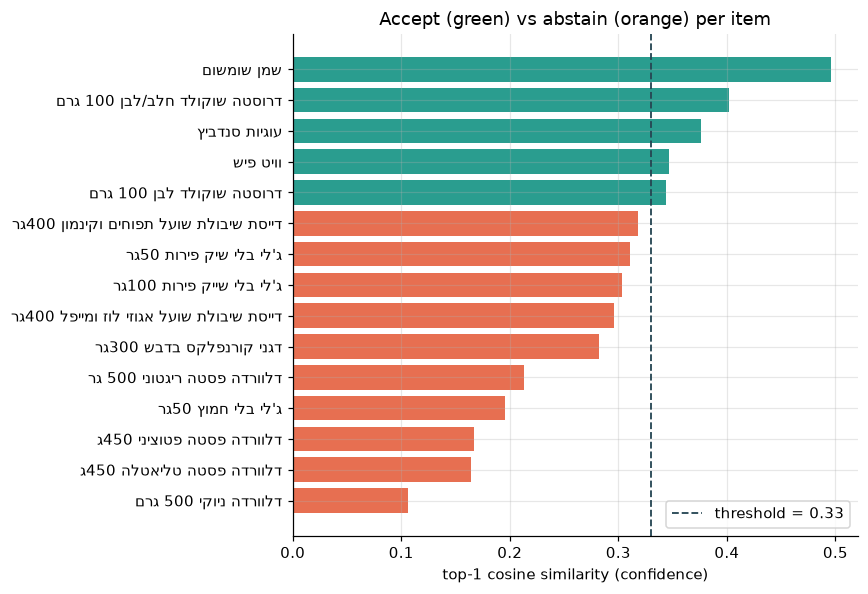

In [9]:
fig, ax = plt.subplots(figsize=(8, 5.5))
o = np.argsort(results["score"].to_numpy())
y = np.arange(len(o))
scores = results["score"].to_numpy()[o]
colors = ["#2a9d8f" if s >= THRESHOLD else "#e76f51" for s in scores]
ax.barh(y, scores, color=colors)
ax.axvline(THRESHOLD, color="#264653", ls="--", lw=1.2, label=f"threshold = {THRESHOLD}")
ax.set_yticks(y)
ax.set_yticklabels(results["item"].to_numpy()[o])
ax.set_xlabel("top-1 cosine similarity (confidence)")
ax.set_title("Accept (green) vs abstain (orange) per item")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Upgrading to the full pipeline (once you have labels)

Zero-shot description similarity is the **floor**. The moment you confirm a
handful of items per COICOP class — even noisily, e.g. by accepting the
high-confidence predictions above and correcting the rest — you can feed them to
the full `TrainingPipeline` exactly as the CLINC150 demo does, and it lights up
the other four signals plus calibration:

```python
from text_classifier import (PipelineConfig, LabelSpace, ClassDefinition,
                             LabeledItem, TrainingPipeline)

label_space = LabelSpace([ClassDefinition(k, d)
                          for k, d in zip(classes.key, classes.description)])
labeled = [LabeledItem(name, coicop_code) for name, coicop_code in confirmed_pairs]

config = PipelineConfig()
config.encoder.kind = "sentence-transformers"
config.encoder.model_name_or_path = MODEL_NAME    # same multilingual encoder
artifacts, report = TrainingPipeline(config).run(labeled, label_space, output_dir="model_dir/")
```

You then get **prototypes** (mean embedding per class), **dense and BM25 kNN**
over labeled examples, an **XGBoost** model fusing all ~28 features, **isotonic**
calibration, and a threshold **tuned for a target accuracy** — with
`InferencePipeline.from_directory("model_dir/")` returning calibrated
`Prediction`s that abstain on their own.

### Takeaways

- A multilingual encoder classifies **Hebrew** names against **English** COICOP
  labels with no translation step — the shared embedding space does the work.
- **Rich class descriptions** (title + *includes* products) are the highest-leverage
  knob in the zero-shot regime; tune them before anything else.
- A **confidence floor** delivers the package's human-in-the-loop behavior even
  before any labels exist; calibration makes that floor principled once they do.